In [41]:
import pandas as pd
import importlib
import process_utils as pu
importlib.reload(pu)

<module 'process_utils' from '/home/sam/Downloads/gh/TSCIL-AL/result/process_utils.py'>

In [42]:
# Create dictionary with dataframes for each dataset
tscil_results = {}

# UCI-HAR
tscil_results['HAR'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [72.8, 89.1],
    'Avg End Acc error': [19.7, 6.1],
    'Avg End Fgt': [22.1, 13.2],
    'Avg End Fgt error': [37.2, 11.4],
    'Avg Cur Acc': [87.2, 97.8],
    'Avg Cur Acc error': [10.4, 1.9]
})

# UWave
tscil_results['UWAVE'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [72.7, 83.2],
    'Avg End Acc error': [2.7, 3.5],
    'Avg End Fgt': [33.6, 20.3],
    'Avg End Fgt error': [3.4, 4.5],
    'Avg Cur Acc': [97.9, 98.4],
    'Avg Cur Acc error': [0.5, 0.4]
})

# DSA
tscil_results['DSA'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [79.6, 96.9],
    'Avg End Acc error': [15.6, 2.2],
    'Avg End Fgt': [23.6, 3.7],
    'Avg End Fgt error': [19.2, 2.7],
    'Avg Cur Acc': [89.9, 100.0],
    'Avg Cur Acc error': [9.6, 0.1]
})

# GRABMyo
tscil_results['GRABMYO'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [46.5, 55.9],
    'Avg End Acc error': [3.2, 5.1],
    'Avg End Fgt': [35.0, 49.4],
    'Avg End Fgt error': [5.7, 5.0],
    'Avg Cur Acc': [73.7, 95.4],
    'Avg Cur Acc error': [4.7, 1.3]
})

# WISDM
tscil_results['WISDM'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [41.7, 51.6],
    'Avg End Acc error': [5.0, 13.7],
    'Avg End Fgt': [27.9, 53.1],
    'Avg End Fgt error': [12.4, 14.3],
    'Avg Cur Acc': [60.7, 95.8],
    'Avg Cur Acc error': [10.2, 2.0]
})

In [ ]:
AL_SETUP = {
    'HAR': (3,300),
    'UWAVE' : (3,25),
    'GRABMYO': (6,20),
    'WISDM': (5,40)
}

In [ ]:
DATASET = 'WISDM'

AL_TOTAL = AL_SETUP[DATASET][0]
AL_BUDGET = AL_SETUP[DATASET][1]

In [45]:
filtered_files = pu.get_filtered_files([DATASET], [AL_TOTAL])
print("Filtered Files:\t", filtered_files)
pu.generate_score_files(filtered_files)

Filtered Files:	 ['uwave/Uncertainty-margin_ER_cycle_3_per_25_uwave.csv', 'uwave/Uncertainty-lc_ER_cycle_3_per_25_uwave.csv', 'uwave/Random_ER_cycle_3_per_25_uwave.csv', 'uwave/Uncertainty-margin_ASER_cycle_3_per_25_uwave.csv', 'uwave/Random_ASER_cycle_3_per_25_uwave.csv', 'uwave/Uncertainty-lc_ASER_cycle_3_per_25_uwave.csv', 'uwave/Uncertainty-entropy_ER_cycle_3_per_25_uwave.csv', 'uwave/Uncertainty-entropy_ASER_cycle_3_per_25_uwave.csv']


## Uncertainty and Random

In [46]:
uncert_la = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', ['uncertainty-', 'random'], AL_TOTAL, AL_BUDGET, 'learning_accuracy')
uncert_la.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-margin-ER,Uncertainty-entropy-ASER,Uncertainty-lc-ER,Uncertainty-lc-ASER,Random-ER,Uncertainty-margin-ASER,Random-ASER,Uncertainty-entropy-ER
0,0,0,0,81.54,81.54,81.54,81.54,81.54,81.54,81.54,81.54
1,0,1,1,92.38,92.38,92.38,92.38,94.57,92.38,94.57,92.38
2,0,2,2,94.08,94.08,94.08,94.08,95.87,94.08,95.87,94.08
3,1,0,3,87.11,86.16,87.11,86.16,79.08,86.16,78.89,87.11
4,1,1,4,90.66,91.59,93.14,91.94,88.78,93.55,80.37,90.23
5,1,2,5,93.17,92.75,93.89,92.37,92.46,94.82,93.24,93.36
6,2,0,6,82.07,75.51,77.80,81.04,80.35,80.43,83.18,80.29
7,2,1,7,89.94,84.27,85.12,88.01,90.35,91.85,86.71,88.98
8,2,2,8,91.15,90.73,93.75,91.09,91.44,93.35,91.53,92.45
9,3,0,9,73.01,75.12,75.93,76.73,77.62,75.88,77.41,75.07


['Random-ER', 'Random-ASER']


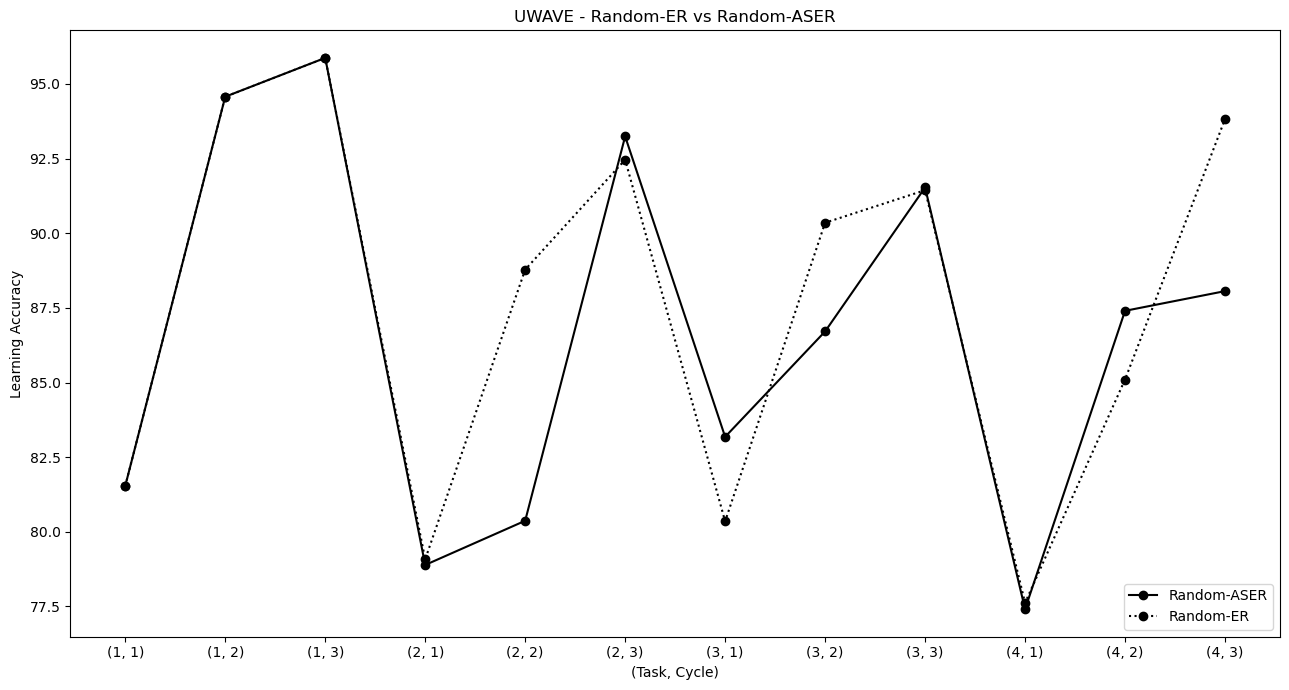

In [47]:
dic = uncert_la[['cycle', 'task', 'Random-ER', 'Random-ASER']]

pu.plot_progress(
    df=dic, 
    loc='lower right',
    title=f"{DATASET} - Random-ER vs Random-ASER",
    X_label="(Task, Cycle)", 
    Y_label="Learning Accuracy")

['Uncertainty-margin-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-lc-ER', 'Uncertainty-lc-ASER', 'Random-ER', 'Uncertainty-margin-ASER', 'Random-ASER', 'Uncertainty-entropy-ER']


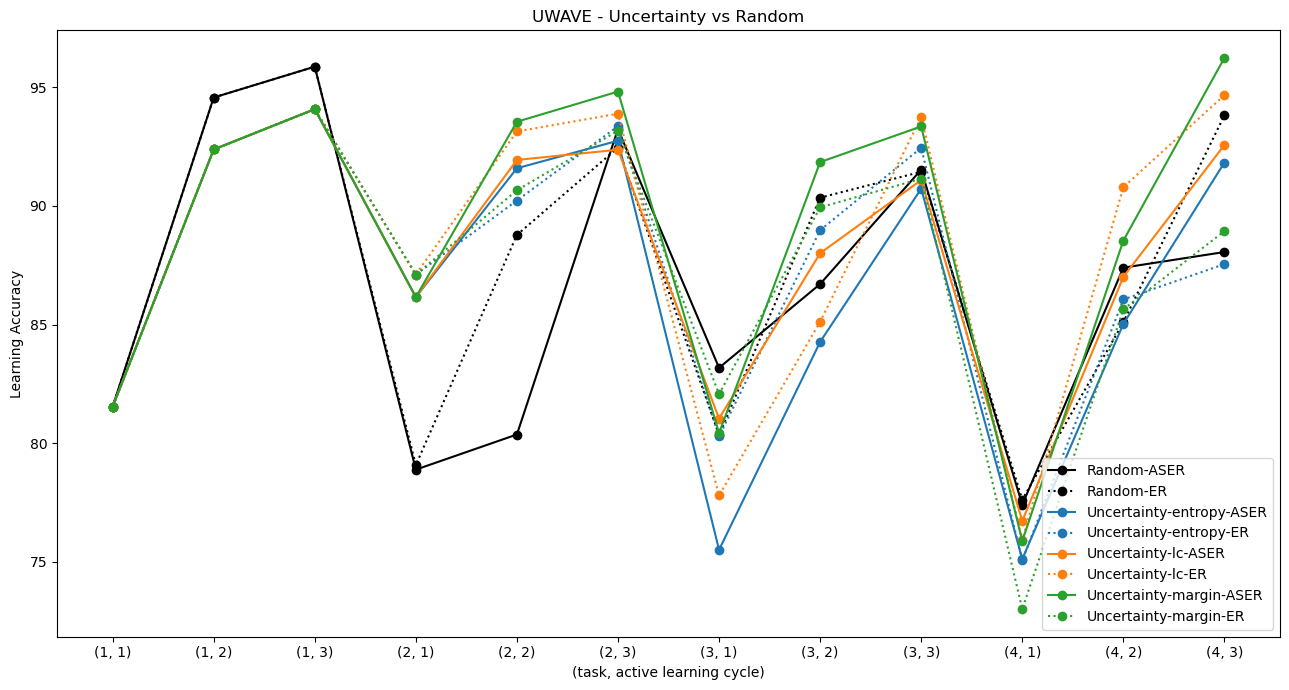

In [48]:
pu.plot_progress(
    df=uncert_la, 
    loc='lower right',
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(task, active learning cycle)", 
    Y_label="Learning Accuracy")

In [49]:
uncert_aa = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', ['uncertainty-', 'random'], AL_TOTAL, AL_BUDGET, 'average_accuracy')
uncert_aa.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-margin-ER,Uncertainty-entropy-ASER,Uncertainty-lc-ER,Uncertainty-lc-ASER,Random-ER,Uncertainty-margin-ASER,Random-ASER,Uncertainty-entropy-ER
0,0,0,0,81.54,81.54,81.54,81.54,81.54,81.54,81.54,81.54
1,0,1,1,92.38,92.38,92.38,92.38,94.57,92.38,94.57,92.38
2,0,2,2,94.08,94.08,94.08,94.08,95.87,94.08,95.87,94.08
3,1,0,3,81.32,81.58,81.32,81.58,78.64,81.58,75.97,81.32
4,1,1,4,85.58,82.52,87.18,83.99,85.36,83.80,79.46,82.82
5,1,2,5,84.52,83.28,85.56,82.86,86.01,83.84,86.57,86.29
6,2,0,6,79.88,70.65,80.78,71.51,79.22,70.05,71.33,77.40
7,2,1,7,79.28,71.91,82.63,75.84,78.66,72.05,74.83,83.04
8,2,2,8,81.51,73.95,82.73,74.36,79.20,70.39,74.60,81.16
9,3,0,9,72.00,57.65,76.99,61.74,73.19,59.19,61.42,70.56


['Uncertainty-margin-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-lc-ER', 'Uncertainty-lc-ASER', 'Random-ER', 'Uncertainty-margin-ASER', 'Random-ASER', 'Uncertainty-entropy-ER']


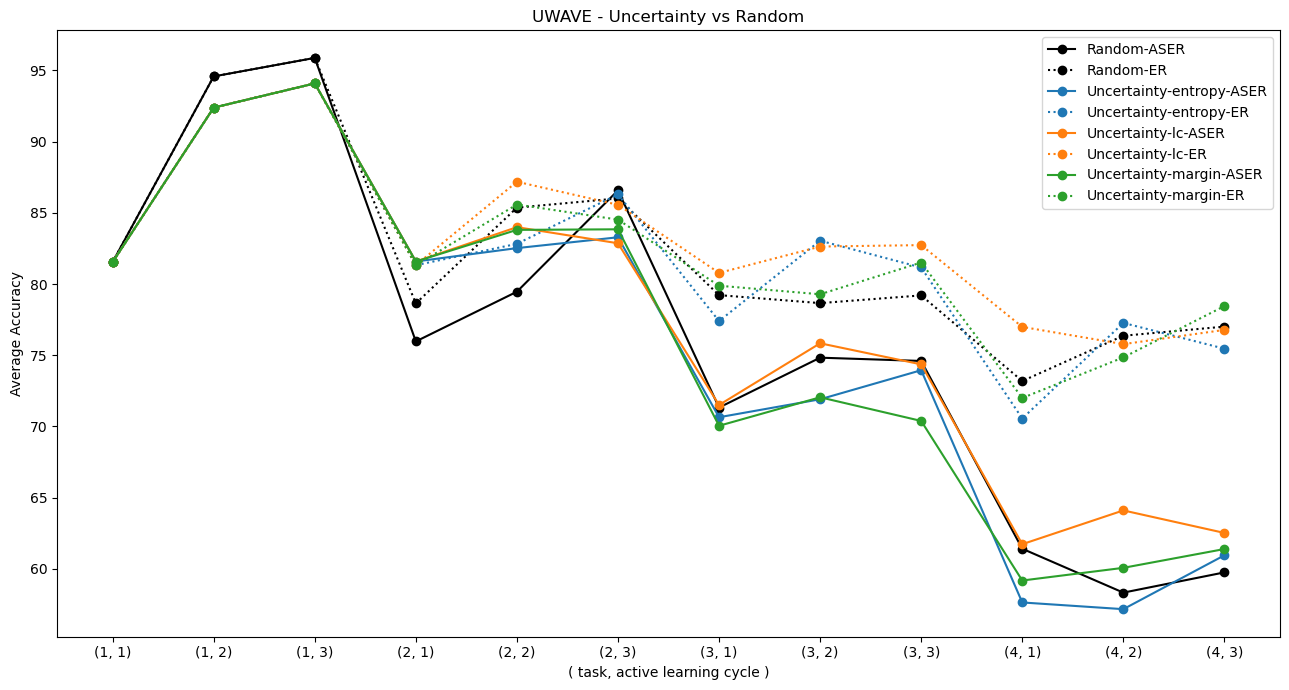

In [50]:
pu.plot_progress(
    df=uncert_aa,
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="( task, active learning cycle )", 
    Y_label="Average Accuracy")

['AA_Random-ASER', 'LA_Random-ER']


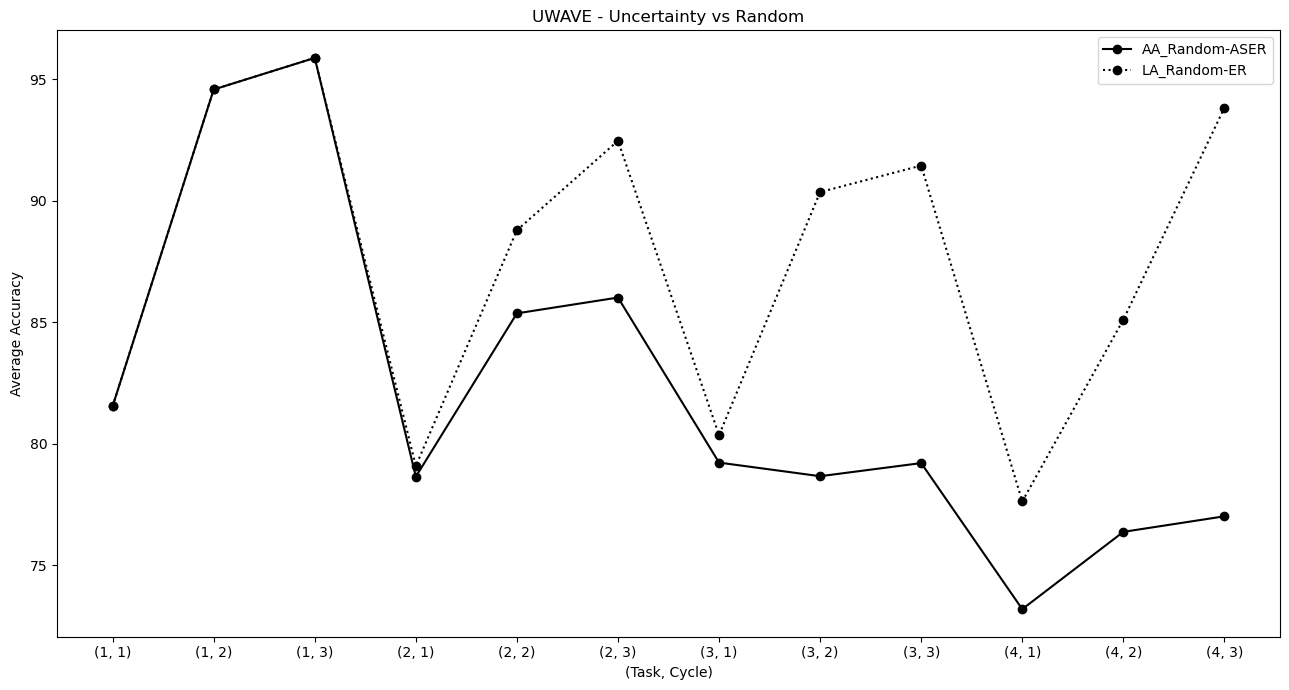

In [51]:
# Create dataframes with prefixes
aa_df = uncert_aa[['task','cycle', 'Random-ER']].copy()
la_df = uncert_la[['Random-ER']].copy()

aa_df.rename(columns={'Random-ER': 'AA_Random-ASER'}, inplace=True)
la_df.rename(columns={'Random-ER': 'LA_Random-ER'}, inplace=True)

df = pd.concat([aa_df, la_df], axis=1)

pu.plot_progress(
    df=df,
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(Task, Cycle)", 
    Y_label="Average Accuracy")

### Task-based

In [52]:
uncer_aa_task = pu.task_level_filter(uncert_aa)
uncer_aa_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-margin-ER,Uncertainty-entropy-ASER,Uncertainty-lc-ER,Uncertainty-lc-ASER,Random-ER,Uncertainty-margin-ASER,Random-ASER,Uncertainty-entropy-ER
0,0,2,2,94.08,94.08,94.08,94.08,95.87,94.08,95.87,94.08
1,1,2,5,84.52,83.28,85.56,82.86,86.01,83.84,86.57,86.29
2,2,2,8,81.51,73.95,82.73,74.36,79.20,70.39,74.60,81.16
3,3,2,11,78.45,60.96,76.78,62.53,77.01,61.40,59.76,75.46


['Uncertainty-margin-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-lc-ER', 'Uncertainty-lc-ASER', 'Random-ER', 'Uncertainty-margin-ASER', 'Random-ASER', 'Uncertainty-entropy-ER']


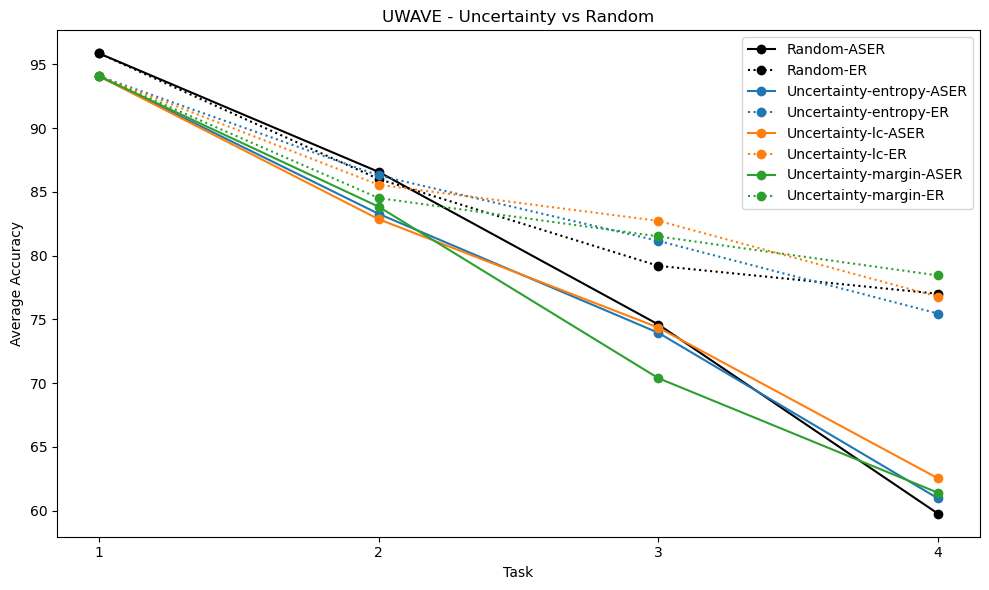

In [53]:
pu.plot_progress(
    df=uncer_aa_task,
    loc = 'upper right',
    figsize=(10, 6),
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="Task", 
    Y_label="Average Accuracy")

In [54]:
uncer_la_task = pu.task_level_filter(uncert_la)
uncer_la_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-margin-ER,Uncertainty-entropy-ASER,Uncertainty-lc-ER,Uncertainty-lc-ASER,Random-ER,Uncertainty-margin-ASER,Random-ASER,Uncertainty-entropy-ER
0,0,2,2,94.08,94.08,94.08,94.08,95.87,94.08,95.87,94.08
1,1,2,5,93.17,92.75,93.89,92.37,92.46,94.82,93.24,93.36
2,2,2,8,91.15,90.73,93.75,91.09,91.44,93.35,91.53,92.45
3,3,2,11,88.94,91.83,94.67,92.57,93.82,96.24,88.06,87.55


['Uncertainty-margin-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-lc-ER', 'Uncertainty-lc-ASER', 'Random-ER', 'Uncertainty-margin-ASER', 'Random-ASER', 'Uncertainty-entropy-ER']


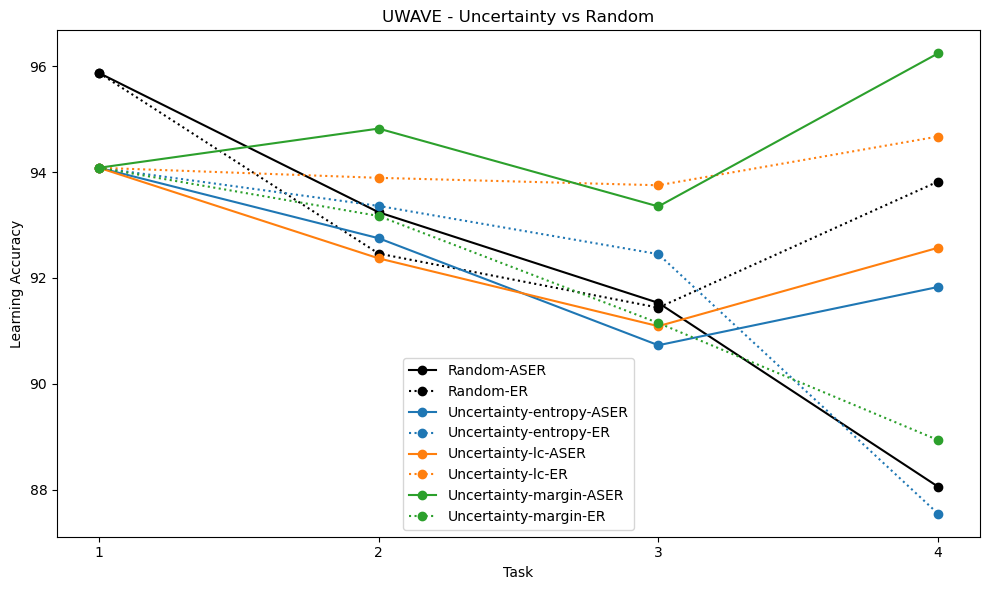

In [55]:
pu.plot_progress(
    df=uncer_la_task,
    loc = 'lower center',
    figsize=(10, 6),
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="Task", 
    Y_label="Learning Accuracy")

In [56]:
pu.add_aser_er_means(uncer_aa_task)
uncer_aa_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,95.87,95.87,94.08,94.08
1,86.57,86.01,83.33,85.46
2,74.60,79.20,72.90,81.80
3,59.76,77.01,61.63,76.90


In [57]:
pu.add_aser_er_means(uncer_la_task)
uncer_la_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,95.87,95.87,94.08,94.08
1,93.24,92.46,93.31,93.47
2,91.53,91.44,91.72,92.45
3,88.06,93.82,93.55,90.39


# Uncertainty Summary

In [58]:
acc_multiple_dataset_multiple_run = pu.get_multiple_al_methods_summary(filtered_files)
results_df = pu.ger_multiple_methods_summary_df(acc_multiple_dataset_multiple_run)
results_df.columns

Index(['Method', 'Avg End Acc', 'Avg End Acc error', 'Avg End Fgt',
       'Avg End Fgt error', 'Avg Cur Acc', 'Avg Cur Acc error', 'Avg Acc',
       'Avg Acc error'],
      dtype='object')

In [59]:
results_df = results_df[['Method', 'Avg End Acc', 'Avg End Acc error', 'Avg End Fgt',
       'Avg End Fgt error', 'Avg Cur Acc', 'Avg Cur Acc error']]

concat_df = pd.concat([results_df, tscil_results[DATASET]])





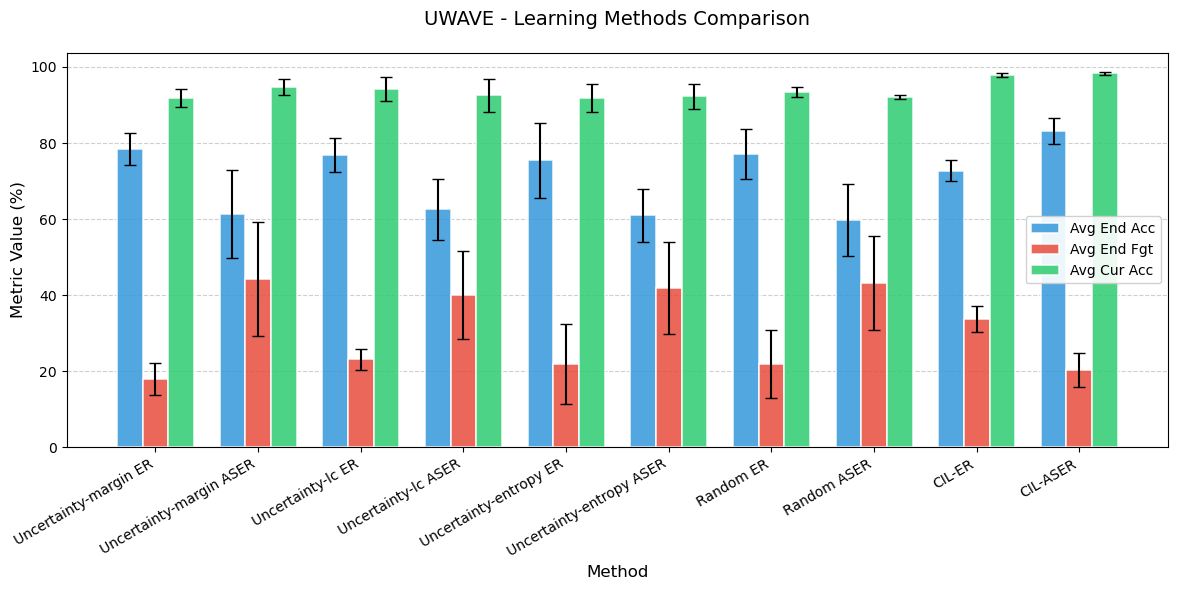

In [60]:
pu.plot_score_values(concat_df, DATASET, 'best')